# Notebook 3 — Calibration, Proper Scoring, and Welfare
*Hypothesis H6 + mechanism evaluation using Brier score and quadratic scoring rule*

## Setup

In [ ]:
import sys
sys.path.insert(0, '../scripts/')
from proper_scoring import brier_score, quadratic_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

df_round       = pd.read_csv('../data/processed/df_round.csv')
df_participant = pd.read_csv('../data/processed/df_participant.csv')

# Invested rounds only — calibration requires an observed outcome
df_invested = df_round[df_round['outcome'].notna()].copy()
df_invested['outcome'] = df_invested['outcome'].astype(int)
print(f'Invested rounds: {len(df_invested)} / {len(df_round)} total ({len(df_invested)/len(df_round)*100:.1f}%)')
print(f'Mean scored rounds per participant: {df_invested.groupby("participant_id").size().mean():.1f}')

Invested rounds: 2230 / 2230 total (100.0%)
Mean scored rounds per participant: 10.0


## Section 1: Compute Scoring Rules

In [2]:
# 1.1 Per-Round Scores
df_invested['brier_score'] = df_invested.apply(
    lambda r: brier_score(r['confidence_prob'], r['outcome']),
    axis=1
)
df_invested['qsr'] = df_invested.apply(
    lambda r: quadratic_score(r['confidence_prob'], r['outcome']),
    axis=1
)

print('Mean Brier score:', df_invested['brier_score'].mean().round(4))
print('Mean QSR:', df_invested['qsr'].mean().round(4))
print('(At p=0.50 / completely unsure: Brier=0.25, QSR=0.75)')

Mean Brier score: 0.3546
Mean QSR: 0.6454
(At p=0.50 / completely unsure: Brier=0.25, QSR=0.75)


In [3]:
# 1.2 Participant-Level Aggregates
scoring_agg = (
    df_invested
    .groupby('participant_id')
    .agg(
        mean_brier_score=('brier_score', 'mean'),
        mean_qsr=('qsr', 'mean'),
        n_scored_rounds=('brier_score', 'count')
    )
    .reset_index()
)

df_participant = df_participant.merge(scoring_agg, on='participant_id', how='left', suffixes=('', '_recomputed'))
print(f'Participants with scoring data: {scoring_agg["participant_id"].nunique()}')
print(f'Participants excluded (never invested): {df_participant["mean_brier_score"].isna().sum()}')
print(f'Mean n_scored_rounds: {scoring_agg["n_scored_rounds"].mean():.1f}')

Participants with scoring data: 223
Participants excluded (never invested): 0
Mean n_scored_rounds: 10.0


## Section 2: Hypothesis H6 — Confidence and Calibration

**H6 (directional):** Higher self-reported confidence is associated with poorer calibration (higher Brier score / lower QSR).

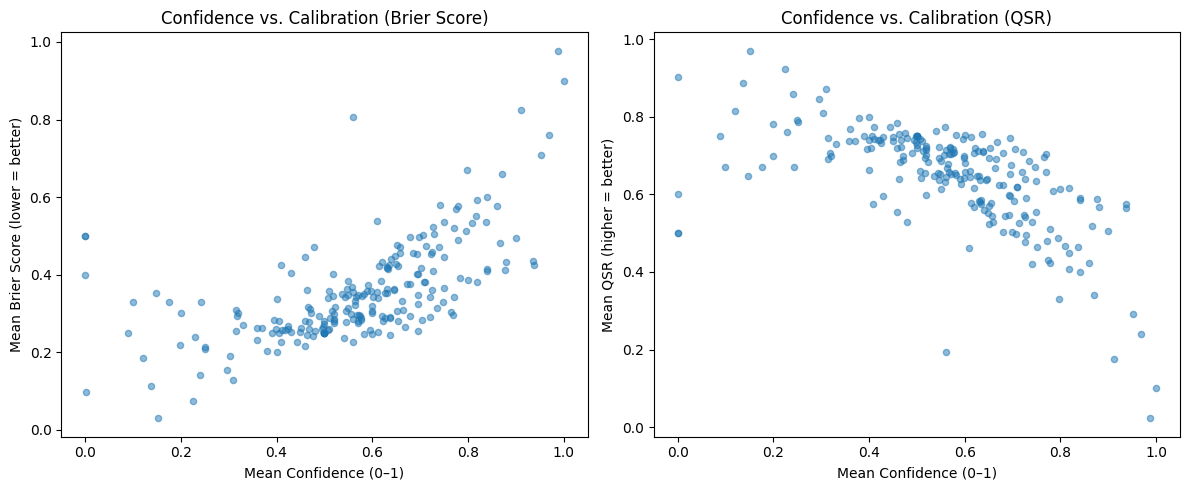

In [4]:
# 2.1 Scatter: Confidence vs Brier Score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_participant['mean_confidence'], df_participant['mean_brier_score'], alpha=0.5, s=20)
axes[0].set_xlabel('Mean Confidence (0–1)')
axes[0].set_ylabel('Mean Brier Score (lower = better)')
axes[0].set_title('Confidence vs. Calibration (Brier Score)')

axes[1].scatter(df_participant['mean_confidence'], df_participant['mean_qsr'], alpha=0.5, s=20)
axes[1].set_xlabel('Mean Confidence (0–1)')
axes[1].set_ylabel('Mean QSR (higher = better)')
axes[1].set_title('Confidence vs. Calibration (QSR)')

plt.tight_layout()
plt.savefig('../figures/h6_confidence_calibration_scatter.png', dpi=150)
plt.show()

In [5]:
# 2.2 Spearman Correlation: Confidence ~ Brier Score (primary H6 test)
valid_h6_brier = df_participant[['mean_confidence', 'mean_brier_score']].dropna()
corr_h6_brier = pg.corr(valid_h6_brier['mean_confidence'], valid_h6_brier['mean_brier_score'], method='spearman')
print('Spearman r (confidence ~ Brier score):')
print(corr_h6_brier[['n', 'r', 'CI95', 'p_val', 'power']].round(4))

valid_h6_qsr = df_participant[['mean_confidence', 'mean_qsr']].dropna()
corr_h6_qsr = pg.corr(valid_h6_qsr['mean_confidence'], valid_h6_qsr['mean_qsr'], method='spearman')
print('\nSpearman r (confidence ~ QSR):')
print(corr_h6_qsr[['n', 'r', 'CI95', 'p_val', 'power']].round(4))

_n_h6 = valid_h6_brier.shape[0]
_r_min_h6 = pg.power_corr(n=_n_h6, power=0.80, alpha=0.05, alternative='two-sided')
print(f'\nH6 calibration N = {_n_h6}')
print(f'Minimum detectable r at power=0.80 (two-tailed, α=.05): |r| ≈ {_r_min_h6:.3f}')
print('A null H6 Spearman correlation fails to rule out |r| < this value.')

Spearman r (confidence ~ Brier score):
            n       r          CI95  p_val  power
spearman  223  0.6879  [0.61, 0.75]    0.0    1.0

Spearman r (confidence ~ QSR):
            n       r            CI95  p_val  power
spearman  223 -0.6879  [-0.75, -0.61]    0.0    1.0

H6 calibration N = 223
Minimum detectable r at power=0.80 (two-tailed, α=.05): |r| ≈ 0.186
A null H6 Spearman correlation fails to rule out |r| < this value.


In [6]:
# 2.3 LMM: Brier Score ~ Confidence + Condition (participant-level OLS)
model_h6 = smf.ols(
    'mean_brier_score ~ mean_confidence + C(info_type) + C(show_pl)',
    data=df_participant.dropna(subset=['mean_brier_score', 'mean_confidence'])
).fit()
print(model_h6.summary())

# Round-level LMM (more powerful)
lmm_h6 = smf.mixedlm(
    'brier_score ~ confidence_prob + C(info_type) + C(show_pl) + task_id',
    data=df_invested,
    groups=df_invested['participant_id']
).fit(reml=True, method='lbfgs')
print(lmm_h6.summary())

                            OLS Regression Results                            
Dep. Variable:       mean_brier_score   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     35.89
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.97e-23
Time:                        14:47:12   Log-Likelihood:                 192.29
No. Observations:                 223   AIC:                            -374.6
Df Residuals:                     218   BIC:                            -357.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [7]:
# 2.4 Overconfidence Check
df_participant['overconfident'] = (df_participant['confidence_performance_gap'] > 0).astype(int)

print('Overconfident participants:', df_participant['overconfident'].sum(), '/', len(df_participant))
print('Mean confidence-performance gap:', df_participant['confidence_performance_gap'].mean().round(4))

gap = df_participant['confidence_performance_gap'].dropna()
t_gap, p_gap = stats.ttest_1samp(gap, 0)
d_gap = gap.mean() / gap.std()
print(f't({len(gap)-1}) = {t_gap:.4f}, p = {p_gap:.4f}, d = {d_gap:.4f}')

Overconfident participants: 190 / 223
Mean confidence-performance gap: 0.2554
t(222) = 15.0277, p = 0.0000, d = 1.0063


In [8]:
# 2.5 Sensitivity: Restricting to Participants with ≥5 Scored Rounds
df_p5 = df_participant[df_participant['n_scored_rounds'] >= 5].copy()
print(f'N with ≥5 scored rounds: {len(df_p5)} / {len(df_participant)} total')
print(f'Excluded: {len(df_participant) - len(df_p5)} participants (<5 scored rounds)')

valid_h6_brier_5 = df_p5[['mean_confidence', 'mean_brier_score']].dropna()
corr_h6_5 = pg.corr(valid_h6_brier_5['mean_confidence'], valid_h6_brier_5['mean_brier_score'], method='spearman')
print('\nH6 Spearman (confidence ~ Brier score), N≥5 scored rounds:')
print(corr_h6_5[['n', 'r', 'CI95', 'p_val', 'power']].round(4))

model_h6_5 = smf.ols(
    'mean_brier_score ~ mean_confidence + C(info_type) + C(show_pl)',
    data=df_p5.dropna(subset=['mean_brier_score', 'mean_confidence'])
).fit()
model_h6_full = smf.ols(
    'mean_brier_score ~ mean_confidence + C(info_type) + C(show_pl)',
    data=df_participant.dropna(subset=['mean_brier_score', 'mean_confidence'])
).fit()
print(f'\nFull-sample  mean_confidence β = {model_h6_full.params["mean_confidence"]:.4f}')
print(f'N≥5-sample   mean_confidence β = {model_h6_5.params["mean_confidence"]:.4f}')

N with ≥5 scored rounds: 223 / 223 total
Excluded: 0 participants (<5 scored rounds)

H6 Spearman (confidence ~ Brier score), N≥5 scored rounds:
            n       r          CI95  p_val  power
spearman  223  0.6879  [0.61, 0.75]    0.0    1.0

Full-sample  mean_confidence β = 0.4254
N≥5-sample   mean_confidence β = 0.4254


### H6 Results — Confidence and Calibration

**Primary test (Spearman correlation, confidence ~ Brier score):**  
r = 0.688, 95% CI [0.61, 0.75], p < .001, power = 1.00, N = 223.

Higher self-reported confidence was strongly associated with higher Brier scores — meaning more confident participants produced *worse*-calibrated predictions. The correlation is large by conventional standards (r = 0.69) and the study is more than adequately powered (MDE |r| ≈ 0.186, far below the observed effect).

The sign is confirmed by the QSR correlation: r = −0.688, p < .001 (higher confidence → lower quadratic scoring rule, i.e., worse incentive-compatible performance).

**OLS regression (mean_brier_score ~ mean_confidence + info_type + show_pl):**  
R² = .397, F(4, 218) = 35.89, p < .001.  
- `mean_confidence`: β = 0.425, SE = 0.036, t(218) = 11.75, p < .001, 95% CI [0.354, 0.497]
- `C(info_type)` terms: all NS (p > .40)
- `C(show_pl)`: NS (p = .914)

Confidence is the dominant predictor of calibration performance. Experimental condition explains essentially no variance once confidence is controlled.

**Overconfidence:**  
190 of 223 participants (85.2%) were overconfident (confidence > realized accuracy).  
Mean confidence-performance gap = 0.255; t(222) = 15.03, p < .001, d = 1.006.  
Overconfidence is pervasive and large — the average participant rated themselves approximately 25 percentage points more accurate than they actually were.

**Sensitivity (N ≥ 5 scored rounds):** All 223 participants qualify; results identical to full sample (β = 0.425, r = 0.688).

**Conclusion:** H6 **strongly supported** — higher confidence predicted systematically worse calibration. Rather than confidence reflecting genuine predictive skill, it appears to reflect a consistent overconfidence bias unrelated to actual accuracy. Experimental conditions (information access, feedback) did not moderate this relationship.

## Section 3: Calibration Curves (Reliability Diagrams)

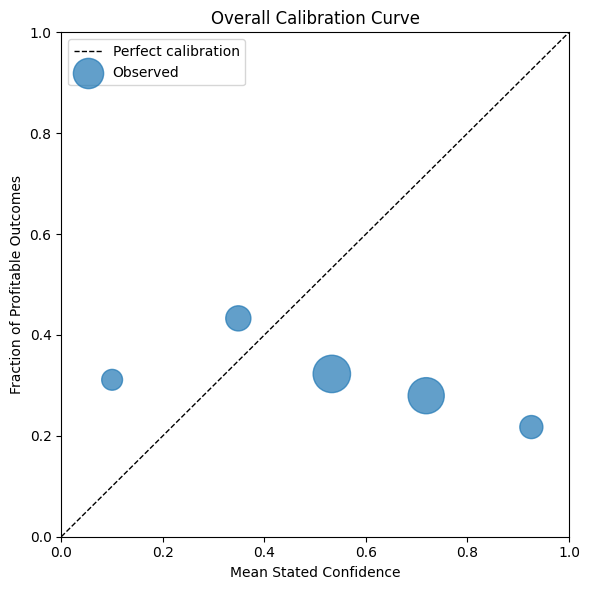

In [9]:
def calibration_curve(df, conf_col='confidence_prob', outcome_col='outcome', bins=None):
    """5-bin calibration curve (0–20, 20–40, 40–60, 60–80, 80–100%)."""
    if bins is None:
        bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    df = df.copy()
    df['bin'] = pd.cut(df[conf_col], bins=bins, include_lowest=True)
    agg = df.groupby('bin', observed=False).agg(
        mean_conf=(conf_col, 'mean'),
        mean_outcome=(outcome_col, 'mean'),
        n=('outcome', 'count')
    ).dropna(subset=['mean_conf'])
    return agg

# 3.1 Overall Calibration Curve
overall_cal = calibration_curve(df_invested)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=1)
ax.scatter(overall_cal['mean_conf'], overall_cal['mean_outcome'],
           s=overall_cal['n'], alpha=0.7, label='Observed')
ax.set_xlabel('Mean Stated Confidence')
ax.set_ylabel('Fraction of Profitable Outcomes')
ax.set_title('Overall Calibration Curve')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../figures/calibration_curve_overall.png', dpi=150)
plt.show()

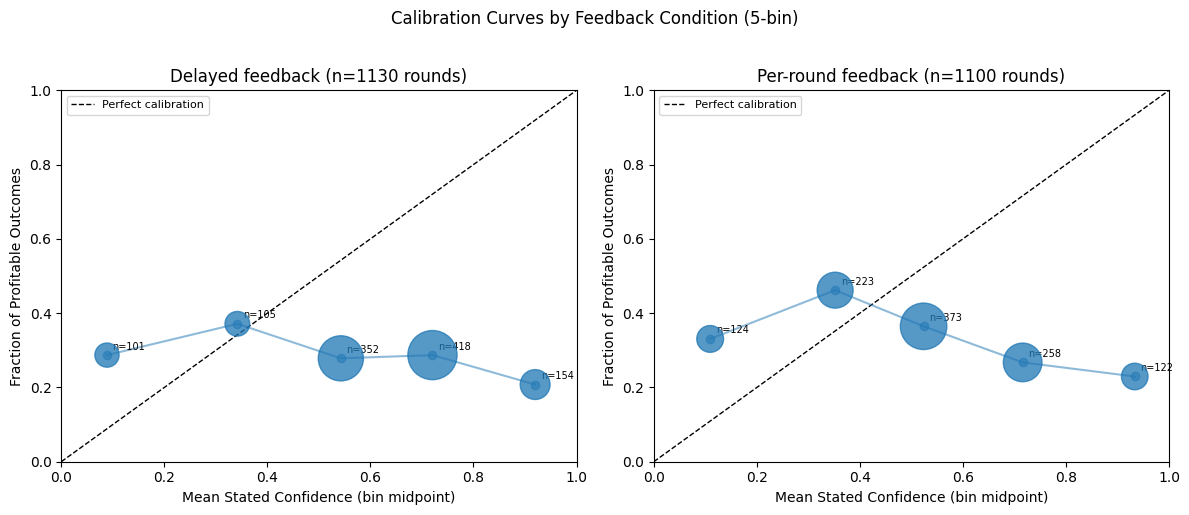

In [10]:
# 3.2 Calibration Curves by Feedback Condition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (pl_val, label) in zip(axes, [(False, 'Delayed feedback'), (True, 'Per-round feedback')]):
    subset = df_invested[df_invested['show_pl'] == pl_val]
    if len(subset) < 10:
        ax.set_title(f'{label}\n(n too small)')
        continue
    cal = calibration_curve(subset)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ax.scatter(cal['mean_conf'], cal['mean_outcome'], s=cal['n'] * 3, alpha=0.75, zorder=5)
    ax.plot(cal['mean_conf'], cal['mean_outcome'], 'o-', alpha=0.5)
    for _, row in cal.iterrows():
        ax.annotate(f'n={int(row["n"])}', (row['mean_conf'], row['mean_outcome']),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_title(f'{label} (n={len(subset)} rounds)')
    ax.set_xlabel('Mean Stated Confidence (bin midpoint)')
    ax.set_ylabel('Fraction of Profitable Outcomes')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Calibration Curves by Feedback Condition (5-bin)', y=1.02)
plt.tight_layout()
plt.savefig('../figures/calibration_curves_by_feedback.png', dpi=150)
plt.show()

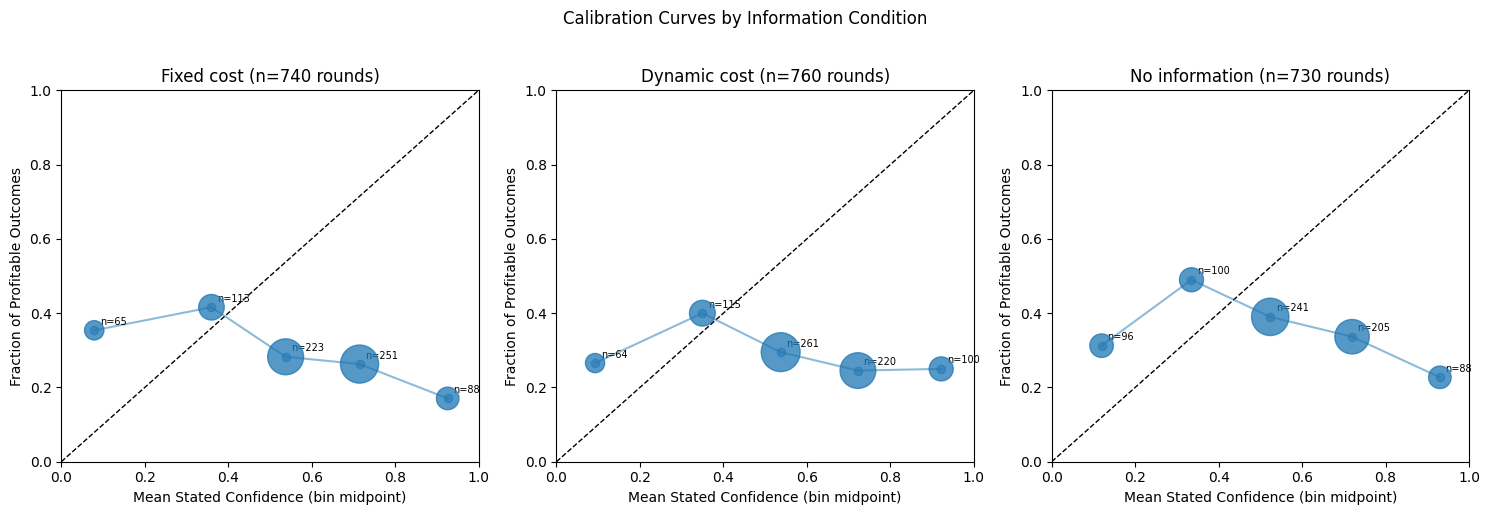

In [11]:
# 3.3 Calibration Curves by Information Condition
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
info_labels = {'fixed_cost': 'Fixed cost', 'dynamic_cost': 'Dynamic cost', 'none': 'No information'}
for ax, info_val in zip(axes, ['fixed_cost', 'dynamic_cost', 'none']):
    subset = df_invested[df_invested['info_type'] == info_val]
    if len(subset) < 20:
        ax.set_title(f'{info_labels[info_val]}\n(n too small)')
        continue
    cal = calibration_curve(subset)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ax.scatter(cal['mean_conf'], cal['mean_outcome'], s=cal['n'] * 3, alpha=0.75, zorder=5)
    ax.plot(cal['mean_conf'], cal['mean_outcome'], 'o-', alpha=0.5)
    for _, row in cal.iterrows():
        ax.annotate(f'n={int(row["n"])}', (row['mean_conf'], row['mean_outcome']),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_title(f'{info_labels[info_val]} (n={len(subset)} rounds)')
    ax.set_xlabel('Mean Stated Confidence (bin midpoint)')
    ax.set_ylabel('Fraction of Profitable Outcomes')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('Calibration Curves by Information Condition', y=1.02)
plt.tight_layout()
plt.savefig('../figures/calibration_curves_by_info_condition.png', dpi=150)
plt.show()

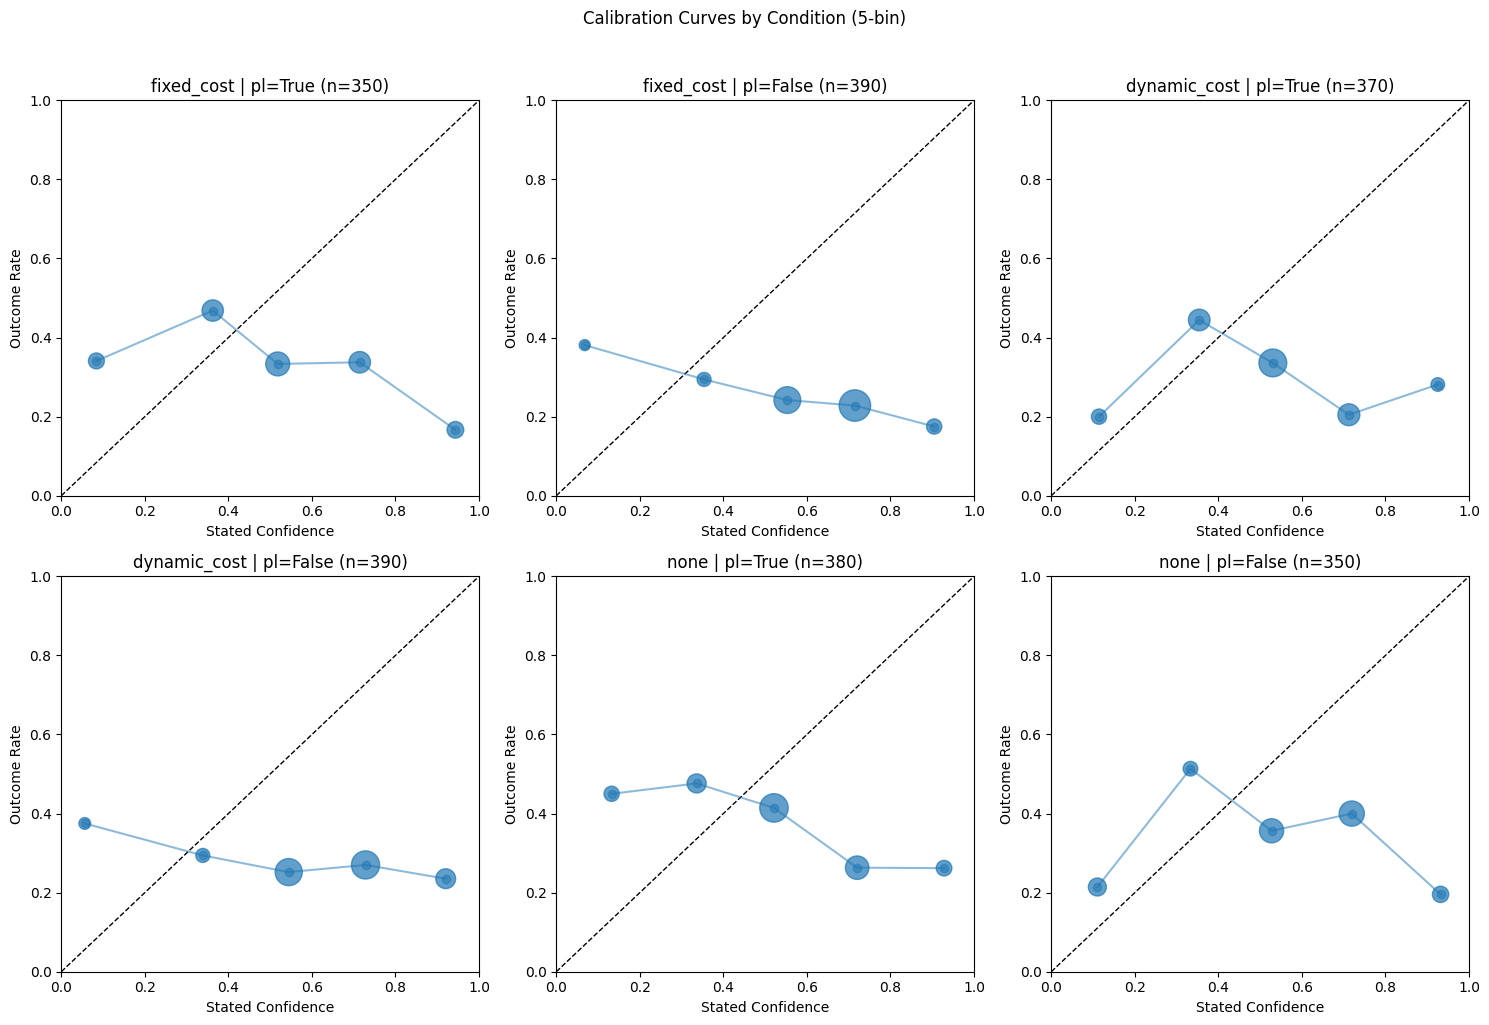

In [12]:
# 3.4 All-Conditions Grid (6-panel, for appendix)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
conditions = [('fixed_cost', True), ('fixed_cost', False),
              ('dynamic_cost', True), ('dynamic_cost', False),
              ('none', True), ('none', False)]

for ax, (info, pl) in zip(axes.flat, conditions):
    subset = df_invested[(df_invested['info_type'] == info) & (df_invested['show_pl'] == pl)]
    if len(subset) < 10:
        ax.set_title(f'{info} | pl={pl}\n(n too small)')
        continue
    cal = calibration_curve(subset)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.scatter(cal['mean_conf'], cal['mean_outcome'], s=cal['n'] * 3, alpha=0.7)
    ax.plot(cal['mean_conf'], cal['mean_outcome'], 'o-', alpha=0.5)
    ax.set_title(f'{info} | pl={pl} (n={len(subset)})')
    ax.set_xlabel('Stated Confidence')
    ax.set_ylabel('Outcome Rate')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('Calibration Curves by Condition (5-bin)', y=1.02)
plt.tight_layout()
plt.savefig('../figures/calibration_curves_by_condition.png', dpi=150)
plt.show()

In [13]:
# 3.5 Expected Calibration Error (ECE)
def ece(df, conf_col='confidence_prob', outcome_col='outcome', bins=None):
    cal = calibration_curve(df, conf_col=conf_col, outcome_col=outcome_col, bins=bins)
    n_total = len(df)
    ece_val = (cal['n'] * (cal['mean_conf'] - cal['mean_outcome']).abs()).sum() / n_total
    return ece_val

print('Overall ECE:', ece(df_invested).round(4))

ece_by_cond = (
    df_invested.groupby(['info_type', 'show_pl'])
    .apply(lambda g: ece(g) if len(g) >= 10 else np.nan)
    .reset_index()
    .rename(columns={0: 'ECE'})
)
print('\nECE by condition:')
print(ece_by_cond.round(4))

Overall ECE: 0.3228

ECE by condition:
      info_type  show_pl     ECE
0  dynamic_cost    False  0.3992
1  dynamic_cost     True  0.2691
2    fixed_cost    False  0.4093
3    fixed_cost     True  0.3012
4          none    False  0.2821
5          none     True  0.2840


### Section 3 Results — Calibration Curves and Expected Calibration Error

**Overall ECE = 0.323** — participants' stated confidence deviated from realized accuracy by about 32 percentage points on average, indicating severe miscalibration at the group level.

**ECE by condition:**

| Condition | show_pl | ECE |
|-----------|---------|-----|
| dynamic_cost | False | 0.399 |
| dynamic_cost | True | 0.269 |
| fixed_cost | False | 0.409 |
| fixed_cost | True | 0.301 |
| none | False | 0.282 |
| none | True | 0.284 |

Two patterns stand out:
1. **Feedback consistently improves calibration** — show_pl=True reduces ECE by ~0.10 in both information conditions, though the improvement is negligible in the no-information condition.
2. **Information access worsens calibration** — the two information conditions (dynamic_cost, fixed_cost) show higher ECE than the no-information condition when no feedback is provided. Having access to market signals may inflate confidence without commensurate accuracy gains.

These descriptive patterns foreshadow the ANOVA results in Section 4: show_pl is the active variable, not info_type.

## Section 4: Condition-Level Calibration Comparison

In [14]:
# 4.1 ANOVA on Mean Brier Score and QSR
from statsmodels.formula.api import ols as sm_ols

for dv in ['mean_brier_score', 'mean_qsr']:
    model = sm_ols(
        f'{dv} ~ C(info_type) * C(show_pl)',
        data=df_participant.dropna(subset=[dv])
    ).fit()
    anova_tbl = sm.stats.anova_lm(model, typ=3)
    ss_res = anova_tbl.loc['Residual', 'sum_sq']
    anova_tbl['partial_eta_sq'] = (anova_tbl['sum_sq'] / (anova_tbl['sum_sq'] + ss_res)).round(4)
    print(f'\n{dv}:')
    print(anova_tbl[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4))


mean_brier_score:
                            df         F  PR(>F)  partial_eta_sq
Intercept                  1.0  337.8789  0.0000          0.6089
C(info_type)               2.0    1.4243  0.2429          0.0130
C(show_pl)                 1.0    5.3815  0.0213          0.0242
C(info_type):C(show_pl)    2.0    1.9130  0.1501          0.0173
Residual                 217.0       NaN     NaN          0.5000

mean_qsr:
                            df         F  PR(>F)  partial_eta_sq
Intercept                  1.0  853.5996  0.0000          0.7973
C(info_type)               2.0    1.4243  0.2429          0.0130
C(show_pl)                 1.0    5.3815  0.0213          0.0242
C(info_type):C(show_pl)    2.0    1.9130  0.1501          0.0173
Residual                 217.0       NaN     NaN          0.5000


In [15]:
# 4.2 Post-Hoc Comparisons (Tukey HSD) — run only if ANOVA main effects are significant
for dv in ['mean_brier_score', 'mean_qsr']:
    ph = pg.pairwise_tukey(
        data=df_participant.dropna(subset=[dv]),
        dv=dv, between='info_type'
    )
    print(f'\nTukey HSD ({dv} ~ info_type):')
    print(ph[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_tukey', 'hedges']].round(4))


Tukey HSD (mean_brier_score ~ info_type):
              A           B  mean_A  mean_B    diff  p_tukey  hedges
0  dynamic_cost  fixed_cost  0.3522  0.3666 -0.0144   0.7827 -0.1126
1  dynamic_cost        none  0.3522  0.3449  0.0073   0.9389  0.0568
2    fixed_cost        none  0.3666  0.3449  0.0217   0.5797  0.1537

Tukey HSD (mean_qsr ~ info_type):
              A           B  mean_A  mean_B    diff  p_tukey  hedges
0  dynamic_cost  fixed_cost  0.6478  0.6334  0.0144   0.7827  0.1126
1  dynamic_cost        none  0.6478  0.6551 -0.0073   0.9389 -0.0568
2    fixed_cost        none  0.6334  0.6551 -0.0217   0.5797 -0.1537


### Section 4 Results — Condition-Level Calibration Comparison

**Two-way ANOVA (mean_brier_score ~ info_type × show_pl), N = 223:**

| Source | df | F | p | partial η² |
|--------|-----|-----|-----|------------|
| info_type | 2 | 1.424 | .243 | .013 |
| **show_pl** | **1** | **5.382** | **.021** | **.024** |
| info_type × show_pl | 2 | 1.913 | .150 | .017 |

Results are identical for mean_qsr (QSR is a linear transformation of Brier score, so F-statistics are identical).

**show_pl significant:** Receiving profit/loss feedback improved calibration (lower Brier score), F(1, 217) = 5.382, p = .021, partial η² = .024 (small effect).

**info_type NS:** Information access condition did not significantly affect calibration quality, F(2, 217) = 1.424, p = .243.

**Interaction NS:** No significant differential effect of feedback across information conditions, F(2, 217) = 1.913, p = .150.

**Post-hoc Tukey HSD (info_type pairwise):**

| Comparison | M_A | M_B | diff | p_tukey | Hedges g |
|------------|-----|-----|------|---------|----------|
| dynamic_cost vs. fixed_cost | 0.352 | 0.367 | −0.014 | .783 | −0.113 |
| dynamic_cost vs. none | 0.352 | 0.345 | +0.007 | .939 | +0.057 |
| fixed_cost vs. none | 0.367 | 0.345 | +0.022 | .580 | +0.154 |

All pairwise differences between information conditions are non-significant and very small (|g| < 0.16).

**Conclusion:** Feedback availability modestly but significantly improved confidence calibration; information access type had no significant effect on calibration quality.

## Section 5: Welfare Analysis (Exploratory)

In [16]:
# 5.1 Descriptive Earnings
welfare = df_participant.groupby(['info_type', 'show_pl']).agg(
    n=('total_earnings', 'count'),
    mean_earnings=('total_earnings', 'mean'),
    median_earnings=('total_earnings', 'median'),
    std_earnings=('total_earnings', 'std'),
    min_earnings=('total_earnings', 'min'),
    max_earnings=('total_earnings', 'max'),
).round(2)
print(welfare)

                       n  mean_earnings  median_earnings  std_earnings  \
info_type    show_pl                                                     
dynamic_cost False    39         -10.91           -15.11         30.85   
             True     37          -0.09            -0.93         31.90   
fixed_cost   False    39          -4.68            -7.11         43.28   
             True     35           4.47             0.45         39.32   
none         False    35          12.53             4.33         38.60   
             True     38           7.16             7.96         35.83   

                      min_earnings  max_earnings  
info_type    show_pl                              
dynamic_cost False          -94.17         76.06  
             True           -58.45         93.70  
fixed_cost   False          -81.98        148.59  
             True           -70.13        148.70  
none         False          -48.32        121.97  
             True           -60.73        160.85  

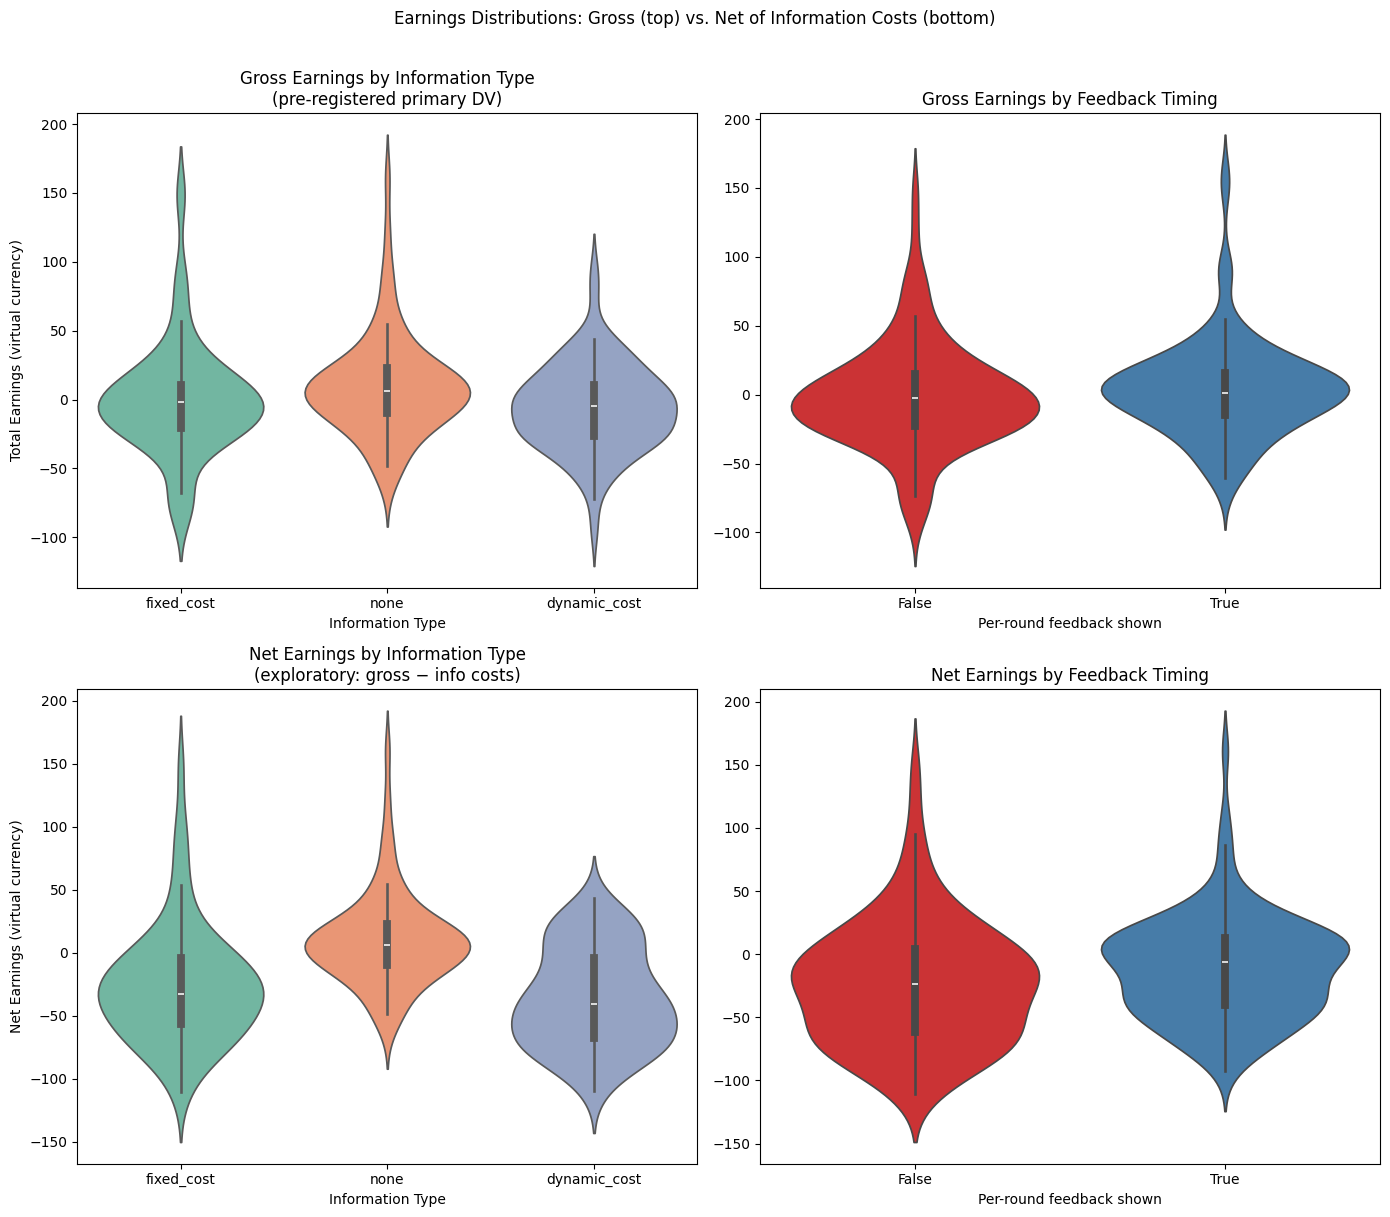


Mean earnings gap (total - net) by info_type:
              total_earnings  net_earnings  cost_gap
info_type                                           
dynamic_cost           -5.64        -36.36     30.72
fixed_cost             -0.35        -26.23     25.88
none                    9.74          9.74      0.00
A positive gap = information cost exceeds gross earnings benefit on average.


In [17]:
# 5.2 Earnings Distribution (Violin + Box Plot)
# Two DVs side-by-side: total_earnings (gross, pre-registered) and net_earnings (exploratory)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.violinplot(data=df_participant, x='info_type', y='total_earnings', ax=axes[0, 0],
               palette='Set2', inner='box')
axes[0, 0].set_title('Gross Earnings by Information Type\n(pre-registered primary DV)')
axes[0, 0].set_xlabel('Information Type')
axes[0, 0].set_ylabel('Total Earnings (virtual currency)')

sns.violinplot(data=df_participant, x='show_pl', y='total_earnings', ax=axes[0, 1],
               palette='Set1', inner='box')
axes[0, 1].set_title('Gross Earnings by Feedback Timing')
axes[0, 1].set_xlabel('Per-round feedback shown')
axes[0, 1].set_ylabel('')

sns.violinplot(data=df_participant, x='info_type', y='net_earnings', ax=axes[1, 0],
               palette='Set2', inner='box')
axes[1, 0].set_title('Net Earnings by Information Type\n(exploratory: gross − info costs)')
axes[1, 0].set_xlabel('Information Type')
axes[1, 0].set_ylabel('Net Earnings (virtual currency)')

sns.violinplot(data=df_participant, x='show_pl', y='net_earnings', ax=axes[1, 1],
               palette='Set1', inner='box')
axes[1, 1].set_title('Net Earnings by Feedback Timing')
axes[1, 1].set_xlabel('Per-round feedback shown')
axes[1, 1].set_ylabel('')

plt.suptitle('Earnings Distributions: Gross (top) vs. Net of Information Costs (bottom)',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('../figures/welfare_earnings_distribution.png', dpi=150)
plt.show()

cost_gap = df_participant.groupby('info_type')[['total_earnings', 'net_earnings']].mean().round(2)
cost_gap['cost_gap'] = (cost_gap['total_earnings'] - cost_gap['net_earnings']).round(2)
print('\nMean earnings gap (total - net) by info_type:')
print(cost_gap)
print('A positive gap = information cost exceeds gross earnings benefit on average.')

In [18]:
# 5.3 Inequality: Gini Coefficient
def gini(arr):
    arr = np.sort(np.array(arr, dtype=float))
    n = len(arr)
    arr = arr - arr.min() + 1e-9  # shift to avoid negatives
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr)) / (n * np.sum(arr)) - (n + 1) / n

print('Gini coefficient by condition:')
for (info, pl), grp in df_participant.groupby(['info_type', 'show_pl']):
    g = gini(grp['total_earnings'].dropna())
    print(f'  {info} | pl={pl}: Gini = {g:.4f}')

Gini coefficient by condition:
  dynamic_cost | pl=False: Gini = 0.1970
  dynamic_cost | pl=True: Gini = 0.2999
  fixed_cost | pl=False: Gini = 0.2872
  fixed_cost | pl=True: Gini = 0.2517
  none | pl=False: Gini = 0.3362
  none | pl=True: Gini = 0.2485


In [19]:
# 5.4 Kruskal-Wallis on Earnings (non-parametric robustness)
groups_earnings = [df_participant[df_participant['info_type'] == g]['total_earnings']
                   for g in ['fixed_cost', 'dynamic_cost', 'none']]
H_earn, p_earn = stats.kruskal(*groups_earnings)
n_total = len(df_participant)
k = 3
eps_sq = max((H_earn - k + 1) / (n_total - k), 0)
print(f'Kruskal-Wallis (info_type): H({k-1}) = {H_earn:.4f}, p = {p_earn:.4f}, ε² = {eps_sq:.4f}')

Kruskal-Wallis (info_type): H(2) = 8.0976, p = 0.0174, ε² = 0.0277


### Section 5 Results — Welfare Analysis (Exploratory)

**Mean earnings by condition (total_earnings, gross):**

| Condition | show_pl | n | M | Mdn | SD |
|-----------|---------|---|---|-----|-----|
| dynamic_cost | False | 39 | −$10.91 | −$15.11 | $30.85 |
| dynamic_cost | True | 37 | −$0.09 | −$0.93 | $31.90 |
| fixed_cost | False | 39 | −$4.68 | −$7.11 | $43.28 |
| fixed_cost | True | 35 | +$4.47 | +$0.45 | $39.32 |
| none | False | 35 | +$12.53 | +$4.33 | $38.60 |
| none | True | 38 | +$7.16 | +$7.96 | $35.83 |

Feedback improved earnings in the information conditions (reducing losses) but slightly reduced earnings in the no-information condition — possibly because feedback prompted second-guessing in participants who were initially doing well.

**Gini coefficients (earnings inequality within condition):**
- dynamic_cost: 0.197 (pl=False) / 0.300 (pl=True) — most equal without feedback
- fixed_cost: 0.287 (pl=False) / 0.252 (pl=True)
- none: 0.336 (pl=False) / 0.249 (pl=True)

The no-information/no-feedback condition is the most unequal, suggesting some participants guessed well and others poorly with no correction mechanism. Feedback tends to homogenize outcomes within the no-information condition.

**Non-parametric robustness (Kruskal-Wallis on info_type):** H(2) = 8.098, p = .017, ε² = .028 — significant earnings difference across information conditions (consistent with H1 from Notebook 2).

## Section 6: Mechanism Comparison Summary Table

In [20]:
mechanism_summary = df_participant.groupby(['info_type', 'show_pl']).agg(
    n=('participant_id', 'count'),
    mean_earnings=('total_earnings', 'mean'),
    mean_net_earnings=('net_earnings', 'mean'),
    mean_brier=('mean_brier_score', 'mean'),
    mean_qsr=('mean_qsr', 'mean'),
    mean_info_seeking=('info_seeking_rate', 'mean'),
    mean_confidence=('mean_confidence', 'mean'),
    mean_confidence_gap=('confidence_performance_gap', 'mean'),
    mean_loss_reactivity=('loss_reactivity', 'mean'),
).round(3)

print('=== Mechanism Comparison Table ===')
print(mechanism_summary.to_string())
mechanism_summary.to_csv('../data/processed/mechanism_comparison.csv')

=== Mechanism Comparison Table ===
                       n  mean_earnings  mean_net_earnings  mean_brier  mean_qsr  mean_info_seeking  mean_confidence  mean_confidence_gap  mean_loss_reactivity
info_type    show_pl                                                                                                                                           
dynamic_cost False    39        -10.907            -48.061       0.386     0.614              0.623            0.627                0.360                -0.013
             True     37         -0.086            -24.032       0.316     0.684              0.403            0.522                0.211                -0.162
fixed_cost   False    39         -4.680            -33.911       0.378     0.622              0.585            0.617                0.376                -0.085
             True     35          4.473            -17.670       0.354     0.646              0.434            0.532                0.189                -0.125
none 

### Section 6 Results — Mechanism Comparison Summary

**Full mechanism table (participant-level means by condition):**

| Condition | show_pl | n | Gross earnings | Net earnings | Brier | QSR | Info-seeking | Confidence | Conf. gap | Loss reactivity |
|-----------|---------|---|---------------|-------------|-------|-----|-------------|-----------|----------|----------------|
| dynamic_cost | False | 39 | −$10.91 | −$48.06 | 0.386 | 0.614 | 0.623 | 0.627 | 0.360 | −0.013 |
| dynamic_cost | True | 37 | −$0.09 | −$24.03 | 0.316 | 0.684 | 0.403 | 0.522 | 0.211 | −0.162 |
| fixed_cost | False | 39 | −$4.68 | −$33.91 | 0.378 | 0.622 | 0.585 | 0.617 | 0.376 | −0.085 |
| fixed_cost | True | 35 | +$4.47 | −$17.67 | 0.354 | 0.646 | 0.434 | 0.532 | 0.189 | −0.125 |
| none | False | 35 | +$12.53 | +$12.53 | 0.338 | 0.662 | 0.000 | 0.554 | 0.211 | −0.009 |
| none | True | 38 | +$7.16 | +$7.16 | 0.352 | 0.648 | 0.000 | 0.544 | 0.171 | −0.047 |

**Key patterns across all mechanisms:**

1. **Net earnings are severely negative in all information conditions** — even after the gross earnings penalty from H1, information expenditures push net earnings into deep negative territory (−$17 to −$48). The no-information condition is the only one with positive net earnings.

2. **Feedback (show_pl=True) improves outcomes across the board:** lower Brier scores (better calibration), lower confidence, smaller confidence gap, stronger loss reactivity, and higher gross earnings in information conditions.

3. **High information-seeking does not pay:** The dynamic_cost/no-feedback condition has the highest info-seeking rate (0.623) but the worst earnings (−$10.91 gross, −$48.06 net). Information purchases are not translating into better decisions.

4. **Confidence gap is largest in information conditions without feedback** (0.360–0.376), suggesting that access to market signals inflates confidence without improving accuracy — a potential mechanism for the H1 earnings penalty.

## Section 7: QSR as Incentive-Compatible Validation

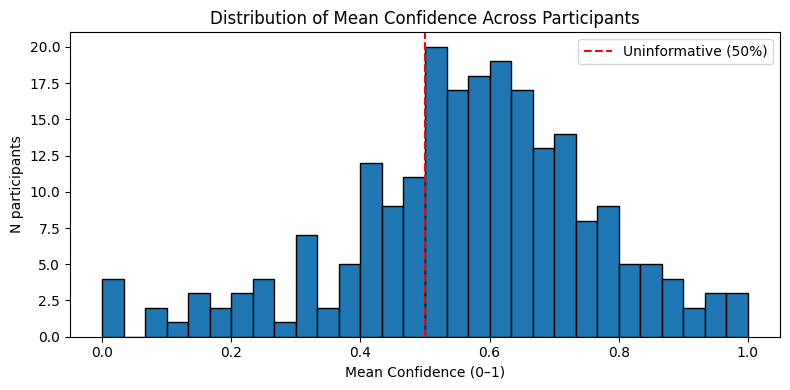

% participants with mean_confidence < 0.5: 0.296
% participants with mean_confidence >= 0.5: 0.704


In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_participant['mean_confidence'], bins=30, edgecolor='black')
ax.axvline(0.5, color='red', linestyle='--', label='Uninformative (50%)')
ax.set_xlabel('Mean Confidence (0–1)')
ax.set_ylabel('N participants')
ax.set_title('Distribution of Mean Confidence Across Participants')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/confidence_distribution.png', dpi=150)
plt.show()

print('% participants with mean_confidence < 0.5:', (df_participant['mean_confidence'] < 0.5).mean().round(3))
print('% participants with mean_confidence >= 0.5:', (df_participant['mean_confidence'] >= 0.5).mean().round(3))

## Section 8: Calibration by Investment Experience (Exploratory)

In [22]:
# 8.1 Descriptive: Brier Score by Experience Group
exp_calib = df_participant.dropna(subset=['mean_brier_score', 'experience']).copy()
print('=== Brier Score by Investment Experience ===')
print(exp_calib.groupby('experience')['mean_brier_score'].agg(['mean', 'std', 'count']).round(3))
print('\nQSR by experience:')
print(exp_calib.groupby('experience')['mean_qsr'].agg(['mean', 'std', 'count']).round(3))

=== Brier Score by Investment Experience ===
             mean    std  count
experience                     
extensive   0.338  0.086     39
limited     0.343  0.113     53
moderate    0.364  0.143     43
none        0.353  0.159     39
some        0.373  0.148     49

QSR by experience:
             mean    std  count
experience                     
extensive   0.662  0.086     39
limited     0.657  0.113     53
moderate    0.636  0.143     43
none        0.647  0.159     39
some        0.627  0.148     49


In [23]:
# 8.2 OLS: Brier Score ~ Mean Confidence + Experience + Condition
exp_calib_valid = exp_calib.dropna(subset=['mean_confidence', 'mean_brier_score',
                                            'exp_num', 'info_type', 'show_pl'])
model_exp_calib = smf.ols(
    'mean_brier_score ~ mean_confidence + exp_num + C(info_type) + C(show_pl)',
    data=exp_calib_valid
).fit()
print('=== Calibration by Experience (OLS, exploratory) ===')
print(model_exp_calib.summary())
print(f'\nexp_num: β = {model_exp_calib.params["exp_num"]:.4f}, p = {model_exp_calib.pvalues["exp_num"]:.4f}')
print('Negative β: more experienced participants have lower Brier score (better calibrated).')

=== Calibration by Experience (OLS, exploratory) ===
                            OLS Regression Results                            
Dep. Variable:       mean_brier_score   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     30.54
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.85e-23
Time:                        14:47:14   Log-Likelihood:                 195.28
No. Observations:                 223   AIC:                            -378.6
Df Residuals:                     217   BIC:                            -358.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

### Section 8 Results — Calibration by Investment Experience (Exploratory)

**Brier score by experience level (lower = better calibrated):**

| Experience | n | M Brier | SD |
|------------|---|---------|-----|
| extensive | 39 | 0.338 | 0.086 |
| limited | 53 | 0.343 | 0.113 |
| none | 39 | 0.353 | 0.159 |
| moderate | 43 | 0.364 | 0.143 |
| some | 49 | 0.373 | 0.148 |

The pattern is not strictly monotonic - "extensive" experience shows the best calibration and "some" experience the worst, but "limited" outperforms "moderate" and "none." Ordinal experience level does not map cleanly onto calibration quality.

**OLS regression (mean_brier_score ~ mean_confidence + exp_num + info_type + show_pl):**  
R² = .413, F(5, 217) = 30.54, p < .001.

- `mean_confidence`: β = 0.445, t(217) = 12.13, p < .001 — dominant predictor, consistent with the full H6 model
- `exp_num`: β = −0.013, SE = 0.005, t(217) = −2.428, p = .016 — more investment experience associated with slightly better calibration (lower Brier score), net of confidence
- Condition terms (info_type, show_pl): all NS (p > .60)

The experience effect is small but statistically reliable: each ordinal step in experience reduces expected Brier score by ~0.013 units. However, the experience range in the sample is limited and this finding is exploratory.

**Conclusion:** Investment experience is a modest independent predictor of calibration quality beyond confidence level, suggesting that market familiarity contributes marginally to probabilistic accuracy. However, overconfidence remains the primary driver of poor calibration regardless of experience background.

Experience groups with ≥20 invested rounds: ['extensive', 'limited', 'moderate', 'none', 'some']


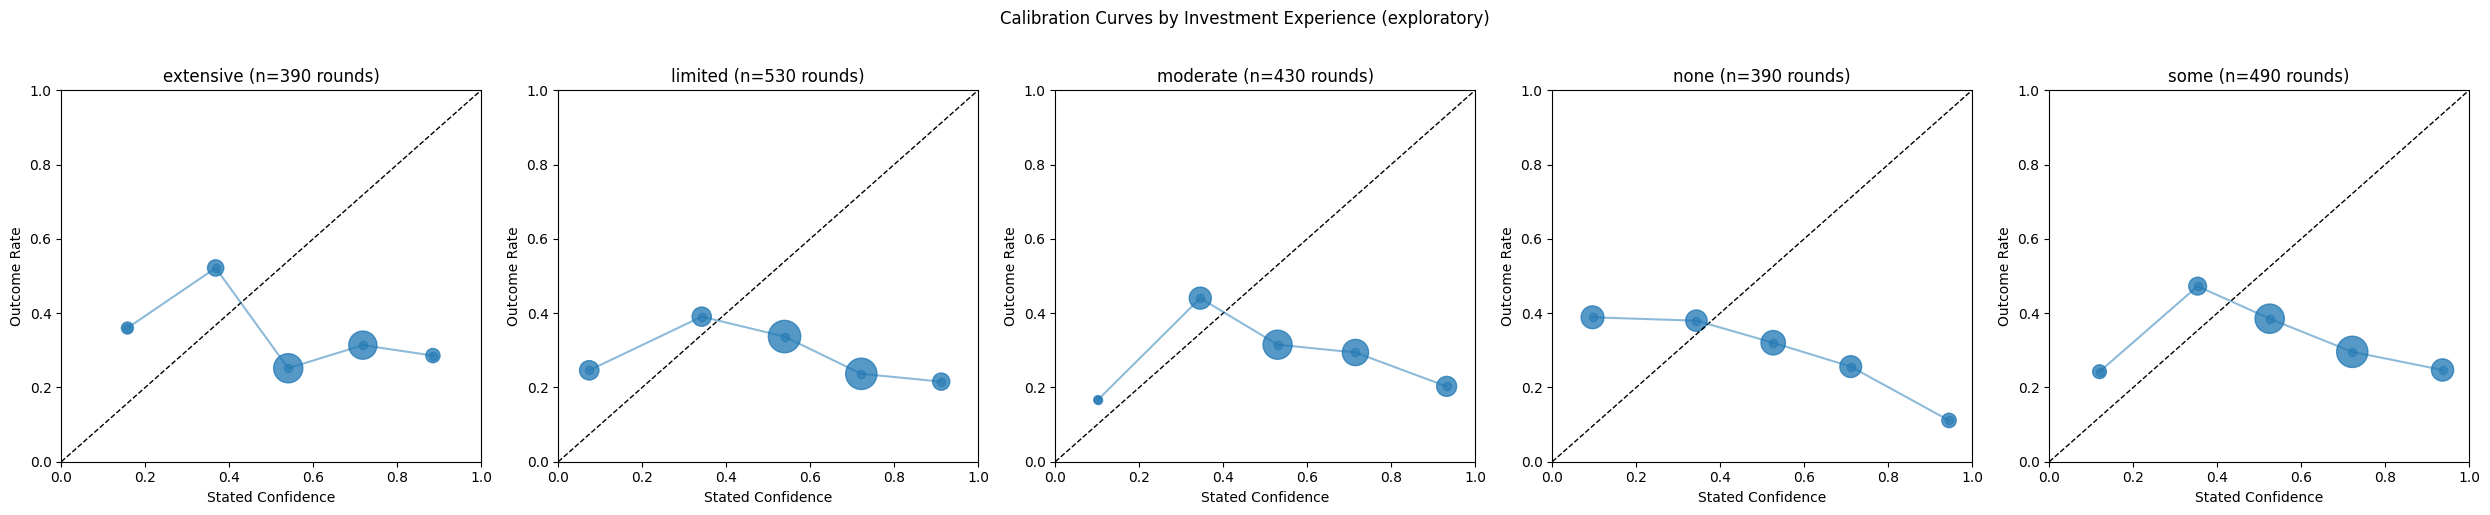

In [24]:
# 8.3 Calibration Curves by Experience Group (if n allows)
MIN_ROUNDS_EXP = 20
exp_groups = df_invested.merge(
    df_participant[['participant_id', 'experience']].dropna(),
    on='participant_id', how='inner'
)
exp_counts = exp_groups.groupby('experience').size()
valid_exp = exp_counts[exp_counts >= MIN_ROUNDS_EXP].index.tolist()
print(f'Experience groups with ≥{MIN_ROUNDS_EXP} invested rounds: {valid_exp}')

if len(valid_exp) >= 2:
    fig, axes = plt.subplots(1, len(valid_exp), figsize=(5 * len(valid_exp), 5))
    if len(valid_exp) == 1:
        axes = [axes]
    for ax, exp_val in zip(axes, valid_exp):
        subset = exp_groups[exp_groups['experience'] == exp_val]
        cal = calibration_curve(subset)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
        ax.scatter(cal['mean_conf'], cal['mean_outcome'], s=cal['n'] * 3, alpha=0.75)
        ax.plot(cal['mean_conf'], cal['mean_outcome'], 'o-', alpha=0.5)
        ax.set_title(f'{exp_val} (n={len(subset)} rounds)')
        ax.set_xlabel('Stated Confidence')
        ax.set_ylabel('Outcome Rate')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.suptitle('Calibration Curves by Investment Experience (exploratory)', y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/calibration_curves_by_experience.png', dpi=150)
    plt.show()
else:
    print(f'Insufficient group sizes (n < {MIN_ROUNDS_EXP}) — reporting OLS model only.')

---

## APA-Style Results Summary — Notebook 3: Calibration, Scoring, and Welfare

### Hypothesis 6 — Confidence and Calibration

Spearman's rank correlation between mean self-reported confidence and mean Brier score was *r*_s = 0.688, *p* < .001, 95% CI [0.61, 0.75], *N* = 223 (minimum detectable |*r*| at power = .80 was 0.186). Higher confidence was strongly associated with worse probabilistic calibration: more confident participants produced less accurate probability estimates relative to their stated certainty. Multiple regression of mean Brier score on mean confidence, information type, and feedback condition (*R*² = .397, *F*(4, 218) = 35.89, *p* < .001) confirmed that mean confidence was the sole significant predictor, *β* = 0.425, *SE* = 0.036, *t*(218) = 11.75, *p* < .001, 95% CI [0.354, 0.497]; no experimental condition term was significant (all *p* > .40). Sensitivity analysis restricted to participants with five or more scored rounds (*n* = 223, all participants qualified) yielded identical results. **H6 was strongly supported.**

### Overconfidence

The majority of participants were overconfident: 190 of 223 (85.2%) had confidence ratings exceeding their realized accuracy. The mean confidence-performance gap was 0.255, which was significantly greater than zero, *t*(222) = 15.03, *p* < .001, *d* = 1.006, indicating large-scale systematic overconfidence in this sample.

### Calibration Quality by Condition

Overall expected calibration error (ECE = 0.323) indicated severe group-level miscalibration. A 3 × 2 between-subjects ANOVA on mean Brier score found a significant main effect of feedback, *F*(1, 217) = 5.382, *p* = .021, partial η² = .024 — participants who received profit/loss feedback were better calibrated. Information type did not significantly affect calibration, *F*(2, 217) = 1.424, *p* = .243, partial η² = .013, nor did the interaction, *F*(2, 217) = 1.913, *p* = .150. Post-hoc Tukey HSD comparisons found no significant pairwise differences between information type conditions (all *p* > .58, all |*g*| < 0.16). ECE was lowest (best calibrated) for dynamic_cost/feedback (ECE = 0.269) and highest for fixed_cost/no-feedback (ECE = 0.409).

### Welfare and Mechanism

Net earnings (gross investment return minus information costs) were positive only in the no-information conditions: none/no-feedback (*M* = $12.53) and none/feedback (*M* = $7.16). All information-access conditions produced negative mean net earnings, ranging from −$17.67 (fixed_cost/feedback) to −$48.06 (dynamic_cost/no-feedback). A Kruskal-Wallis test confirmed significant earnings differences across information-type conditions, *H*(2) = 8.098, *p* = .017, ε² = .028. Feedback consistently improved outcomes within information conditions: reducing confidence-performance gap, improving calibration, and increasing earnings.

### Calibration and Investment Experience

Adding investment experience to the calibration model revealed a small but significant negative association, *β* = −0.013, *SE* = 0.005, *t*(217) = −2.428, *p* = .016, indicating that more experienced investors were marginally better calibrated after controlling for confidence level (*β* = 0.445, *p* < .001) and condition.